In [3]:
pip install networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

def carica_e_disegna_grafo_layered(filepath, max_archi_da_disegnare=300):
    if not os.path.exists(filepath):
        print(f"[-] Errore: Il file '{filepath}' non è stato trovato.")
        return

    print(f"[+] Apertura del file in corso: {filepath}")
    with open(filepath, 'r', encoding='utf-8') as file:
        righe = [line.strip() for line in file if line.strip()]

    if not righe:
        print("[-] Errore: Il file è vuoto.")
        return

    try:
        header = list(map(int, righe[0].split()))
        n, m, s, t, k, numero_colori = header
    except Exception as e:
        print(f"[-] Errore nel parsing dell'intestazione: {e}")
        return

    G = nx.DiGraph()
    G.add_nodes_from(range(1, n + 1))
    
    for idx, riga in enumerate(righe[1:], start=2):
        elementi = riga.split()
        if len(elementi) >= 4:
            try:
                u, v, w, c = map(int, elementi[:4])
                G.add_edge(u, v, weight=w, color=c)
            except ValueError:
                pass

    totale_archi = G.number_of_edges()
    if totale_archi > max_archi_da_disegnare:
        print(f"[!] Mostro un sotto-grafo con i primi {max_archi_da_disegnare} archi su {totale_archi}.")
        archi_selezionati = list(G.edges(data=True))[:max_archi_da_disegnare]
        plot_G = nx.DiGraph()
        plot_G.add_edges_from(archi_selezionati)
        if s not in plot_G: plot_G.add_node(s)
        if t not in plot_G: plot_G.add_node(t)
    else:
        plot_G = G

    # Rimuovi i nodi completamente isolati (tranne sorgente e destinazione)
    nodi_isolati = list(nx.isolates(plot_G))
    da_rimuovere = [nodo for nodo in nodi_isolati if nodo != s and nodo != t]
    plot_G.remove_nodes_from(da_rimuovere)

    # === NOVITÀ: CALCOLO DEI LIVELLI PER IL LAYERED GRAPH ===
    # 1. Calcoliamo la distanza in salti da 's' usando una visita in ampiezza (BFS)
    try:
        distanze_da_s = nx.single_source_shortest_path_length(plot_G, s)
    except nx.NetworkXError:
        distanze_da_s = {s: 0}

    max_livello = max(distanze_da_s.values()) if distanze_da_s else 0

    # 2. Assegniamo l'attributo 'layer' a ogni nodo nel grafo
    for nodo in plot_G.nodes():
        if nodo in distanze_da_s:
            plot_G.nodes[nodo]['layer'] = distanze_da_s[nodo]
        elif nodo == t:
            # Se la destinazione non è raggiungibile nel sub-grafo, la forziamo all'ultimo livello a destra
            plot_G.nodes[nodo]['layer'] = max_livello + 1 
        else:
            # Altri nodi irraggiungibili da 's' vengono messi in un livello isolato
            plot_G.nodes[nodo]['layer'] = max_livello + 2

    plt.figure(figsize=(15, 10))
    
    # 3. Utilizziamo il layout multipartito. 
    # align='vertical' impila i nodi dello stesso livello in verticale, facendo scorrere il grafo da sinistra a destra.
    pos = nx.multipartite_layout(plot_G, subset_key='layer', align='vertical')
    
    # Per schiacciare visivamente i livelli molto larghi e allargarli orizzontalmente,
    # possiamo manipolare manualmente le coordinate pos (opzionale ma consigliato per i grafi a livelli)
    for nodo, (x, y) in pos.items():
        pos[nodo] = (x * 2.0, y)  # Allarga lo spazio orizzontale tra i livelli

    # =========================================================

    # Mappatura Colori
    colori_archi_id = [plot_G[u][v]['color'] for u, v in plot_G.edges()]
    colori_unici = sorted(list(set(colori_archi_id)))
    cmap = cm.get_cmap('tab20', max(len(colori_unici), 1))
    mappa_colori = {c_id: cmap(i % 20) for i, c_id in enumerate(colori_unici)}
    edge_colors = [mappa_colori[c] for c in colori_archi_id]

    node_colors = []
    node_sizes = []
    for nodo in plot_G.nodes():
        if nodo == s:
            node_colors.append('#2ecc71')
            node_sizes.append(650)
        elif nodo == t:
            node_colors.append('#e74c3c')
            node_sizes.append(650)
        else:
            node_colors.append('#3498db')
            node_sizes.append(150)

    # Rendering
    nx.draw_networkx_nodes(plot_G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors='white')
    
    if plot_G.number_of_nodes() < 70:
        nx.draw_networkx_labels(plot_G, pos, font_size=8, font_color='white', font_weight='bold')
    else:
        etichette = {n_id: f"S({n_id})" if n_id == s else f"T({n_id})" for n_id in [s, t] if n_id in plot_G}
        nx.draw_networkx_labels(plot_G, pos, labels=etichette, font_size=11, font_color='black', font_weight='bold')

    nx.draw_networkx_edges(
        plot_G, pos,
        edge_color=edge_colors,
        width=1.2,
        arrowsize=10,
        arrows=True,
        alpha=0.7,
        connectionstyle='arc3,rad=0.05' # Curvatura leggerissima per non sporcare i livelli
    )

    plt.title(f"Grafo Layered kCSP\nFlusso: Sorgente (Verde) $\\rightarrow$ Destinazione (Rossa)\nI nodi sono allineati in base alla distanza in salti dalla sorgente", fontsize=14, pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


[+] Apertura del file in corso: new-instances/3.txt


/var/folders/nf/cnvgd5gn5j945z10gyw6kxgm0000gn/T/ipykernel_17248/1437394201.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(len(colori_unici), 1))


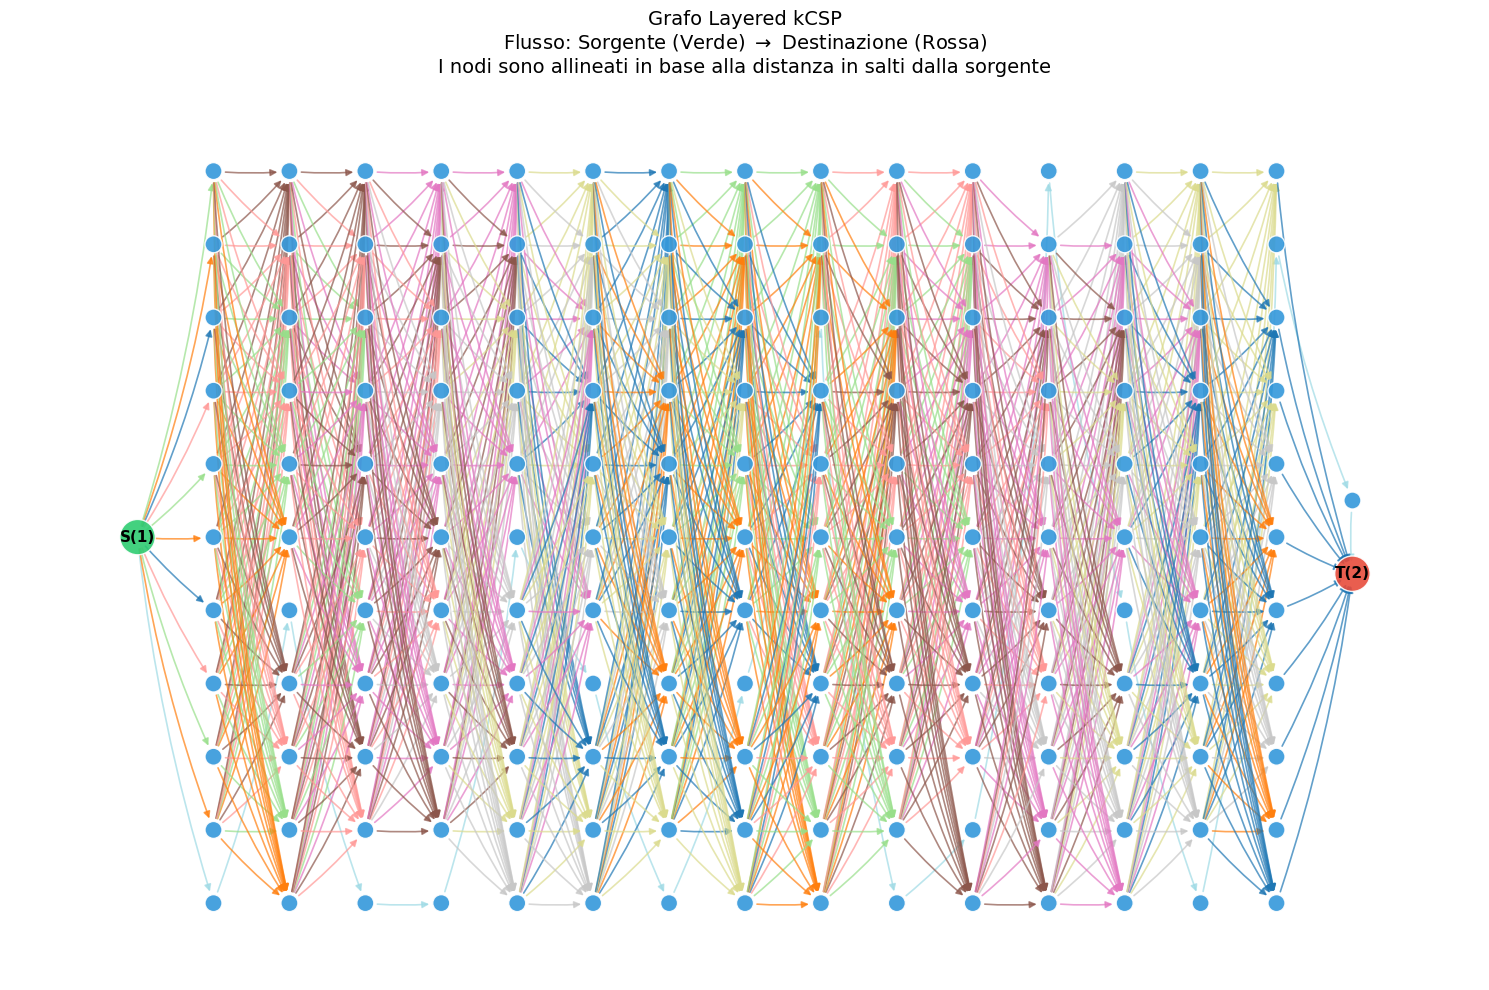

In [11]:
# Sostituisci con il nome reale o con il percorso del tuo file txt
percorso_file = "new-instances/3.txt" 
#percorso_file = "castro-instances/3.txt" 
# Esegui la funzione
carica_e_disegna_grafo_layered(percorso_file, max_archi_da_disegnare=2000)